# Puget Sound Hypoxia Analysis
This notebook consolidates all key plots including vertical profiles, DO distributions, lagged correlations, and hypoxia severity metrics.

Data Processing and Calculations: 
These cells include the full data extraction and time series aggregation used prior to plotting.

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arrow
import os
from scipy.stats import pearsonr, linregress
from collections import defaultdict
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns

output_dir = "generated_figures"
os.makedirs(output_dir, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(os.path.join(output_dir, f"{name}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig)

# get_file_path, DATA_DIR, REGIONS, STRAT_DEPTHS, HYPOXIA_THRESHOLD, vol_3d
all_DO = defaultdict(list)
ts_DO_profiles = defaultdict(list)
ts_temp_profiles = defaultdict(list)
ts_salt_profiles = defaultdict(list)
ts_rem_profiles = defaultdict(list)
ts_do2_profiles = defaultdict(list)

ts_temp = defaultdict(list)
ts_salt = defaultdict(list)
ts_rem = defaultdict(list)
ts_do2 = defaultdict(list)

annual_hypoxic_days = defaultdict(lambda: defaultdict(int))
annual_hypoxic_volume = defaultdict(lambda: defaultdict(float))
normalized_hypoxic_volume = defaultdict(lambda: defaultdict(float))

annual_min_DO = defaultdict(lambda: defaultdict(lambda: np.inf))
annual_min_DO_coords = defaultdict(dict)
annual_min_DO_temp = defaultdict(dict)
annual_min_DO_salt = defaultdict(dict)
annual_min_DO_rem = defaultdict(dict)
annual_min_DO_do2 = defaultdict(dict)

daily_min_DO_series = defaultdict(list)
daily_min_temp_series = defaultdict(list)
daily_min_salt_series = defaultdict(list)
daily_min_rem_series = defaultdict(list)
daily_min_do2_series = defaultdict(list)

annual_mean_temp = defaultdict(lambda: defaultdict(float))
annual_mean_salt = defaultdict(lambda: defaultdict(float))
annual_mean_rem = defaultdict(lambda: defaultdict(float))
annual_mean_do2 = defaultdict(lambda: defaultdict(float))
annual_day_counts = defaultdict(lambda: defaultdict(int))

dates = []


In [ ]:
DATA_DIR = '/ocean/atall/MOAD/Model/202410b/oxygen/'
MESH_FILE = '/ocean/sallen/allen/research/MEOPAR/grid/mesh_mask202108.nc'

START_YEAR = 2012
END_YEAR = 2024

REGIONS = {
    'Liplip Kinney': (252, 260, 165, 174),
    'Lynch Cove': (129, 140, 67, 76),
    'Penn Cove': (268, 280, 210, 218),#(275, 297, 204, 216),
    'Holmes Harbor': (268, 280, 165, 174),
}
STRAT_DEPTHS = {
    'Liplip Kinney': {'surface': (0, 10), 'bottom': (20, 50)},
    'Lynch Cove': {'surface': (0, 10), 'bottom': (20, 50)},
    'Penn Cove': {'surface': (0, 10), 'bottom': (20, 50)},
    'Holmes Harbor': {'surface': (0, 10), 'bottom': (20, 50)},
}

# Hypoxia threshold in mmol/m3
HYPOXIA_THRESHOLD = 63.0


mesh = xr.open_dataset(MESH_FILE)
depth_array = mesh['gdept_0'][0].values
e1t = mesh['e1t'][0, :, :]
e2t = mesh['e2t'][0, :, :]
e3t = mesh['e3t_0'][0, :, :, :]
tmask = mesh['tmask'][0, :, :, :]
vol_cell = e1t * e2t
vol_3d = e3t * vol_cell
vol_3d = vol_3d * tmask

mesh = xr.open_dataset(MESH_FILE)
depth_array = mesh['gdept_0'][0].values  # depth levels
depth_array_1d = mesh['gdept_0'][0, :, 0, 0].values  # for AOU plots
np.savetxt("depth_levels.txt", depth_array_1d)  # for AOU plots

# Function to build filename paths
def get_file_path(base_dir, date_obj, file_type):
    yr2 = date_obj.strftime("%y")
    Month = date_obj.strftime("%b").lower()
    day_num = date_obj.day
    year = date_obj.year
    month = date_obj.month
    
    #suffix = '_chem_T.nc' 
    if file_type == 'chem': suffix = '_chem_T.nc' 
    elif file_type =='grid': suffix = '_grid_T.nc' 
    elif file_type =='diag': suffix = '_diag_T.nc'
    fname = f'SalishSea_1d_{year}{month:02}{day_num:02}_{year}{month:02}{day_num:02}{suffix}'
    fpath = os.path.join(base_dir, f"{day_num:02}{Month}{yr2}", fname)
    return fpath


In [3]:
print("Starting data processing...")
start_date = arrow.get(START_YEAR, 1, 1)
end_date = arrow.get(END_YEAR, 12, 31)
for day in arrow.Arrow.range('day', start_date, end_date):
    fchem = get_file_path(DATA_DIR, day, 'chem')
    fgrid = get_file_path(DATA_DIR, day, 'grid')
    fdiag = get_file_path(DATA_DIR, day, 'diag')

    if not (os.path.exists(fchem) and os.path.exists(fgrid)):
        continue

    with xr.open_dataset(fchem) as ds_chem, xr.open_dataset(fgrid) as ds_grid, xr.open_dataset(fdiag) as ds_diag:
        for region, (ii1, ii2, jj1, jj2) in REGIONS.items():
            # Dissolved oxygen full water column
            DO = ds_chem['dissolved_oxygen'][0, :, jj1:jj2, ii1:ii2]
            DO = xr.where(DO == 0, np.nan, DO)
            DO_profile = DO.mean(dim=['y', 'x'], skipna=True).values
            ts_DO_profiles[region].append((day.datetime, DO_profile))
            all_DO[region].append(DO.values.flatten())

            # Temperature and Salinity full water column
            temp = ds_grid['votemper'][0, :, jj1:jj2, ii1:ii2]
            temp = xr.where(temp == 0, np.nan, temp)
            temp_profile = temp.mean(dim=['y', 'x'], skipna=True).values
            ts_temp_profiles[region].append((day.datetime, temp_profile))
            salt = ds_grid['vosaline'][0, :, jj1:jj2, ii1:ii2]
            salt = xr.where(salt == 0, np.nan, salt)
            salt_profile = salt.mean(dim=['y', 'x'], skipna=True).values
            ts_salt_profiles[region].append((day.datetime, salt_profile))

            mean_temp = float(np.nanmean(temp))
            mean_salt = float(np.nanmean(salt))
            ts_temp[region].append((day.datetime, mean_temp))
            ts_salt[region].append((day.datetime, mean_salt))

            # Remin and do2/dt full water column
            rem = ds_diag['REM_O2'][0, :, jj1:jj2, ii1:ii2]
            rem = xr.where(rem == 0, np.nan, rem)
            rem_profile = rem.mean(dim=['y', 'x'], skipna=True).values
            ts_rem_profiles[region].append((day.datetime, rem_profile))
            do2 = ds_diag['RATE_O2'][0, :, jj1:jj2, ii1:ii2]
            do2 = xr.where(do2 == 0, np.nan, do2)
            do2_profile = do2.mean(dim=['y', 'x'], skipna=True).values
            ts_do2_profiles[region].append((day.datetime, do2_profile))

            mean_rem = float(np.nanmean(rem))
            mean_do2 = float(np.nanmean(do2))
            ts_rem[region].append((day.datetime, mean_rem))
            ts_do2[region].append((day.datetime, mean_do2))
            
            hypoxic_mask = DO < HYPOXIA_THRESHOLD
            region_vol = vol_3d[:, jj1:jj2, ii1:ii2]
            total_region_volume = region_vol.sum().item()
            hypoxic_volume = (hypoxic_mask * region_vol).sum().item()

            if hypoxic_volume > 0:
                annual_hypoxic_days[region][day.year] += 1
                annual_hypoxic_volume[region][day.year] += hypoxic_volume

                normalized_volume = hypoxic_volume / total_region_volume
                normalized_hypoxic_volume[region][day.year] += normalized_volume

            # Compute min DO and location
            daily_min_do = np.nanmin(DO.values)
            if np.isnan(DO.values).all():
                continue
            idx_min = np.unravel_index(np.nanargmin(DO.values), DO.shape)
            d_idx, y_idx, x_idx = idx_min

            # Check for annual minimum
            if daily_min_do < annual_min_DO[region][day.year]:
                annual_min_DO[region][day.year] = daily_min_do
                annual_min_DO_coords[region][day.year] = idx_min
                annual_min_DO_temp[region][day.year] = temp.values[d_idx, y_idx, x_idx]
                annual_min_DO_salt[region][day.year] = salt.values[d_idx, y_idx, x_idx]
                annual_min_DO_rem[region][day.year] = rem.values[d_idx, y_idx, x_idx]
                annual_min_DO_do2[region][day.year] = do2.values[d_idx, y_idx, x_idx]

            # Store daily time series for plotting
            daily_min_DO_series[region].append((day.datetime, daily_min_do))
            daily_min_temp_series[region].append((day.datetime, temp.values[d_idx, y_idx, x_idx]))
            daily_min_salt_series[region].append((day.datetime, salt.values[d_idx, y_idx, x_idx]))
            daily_min_rem_series[region].append((day.datetime, rem.values[d_idx, y_idx, x_idx]))
            daily_min_do2_series[region].append((day.datetime, do2.values[d_idx, y_idx, x_idx]))

            annual_mean_temp[region][day.year] += np.nanmean(temp).item()
            annual_mean_salt[region][day.year] += np.nanmean(salt).item()
            annual_mean_rem[region][day.year] += np.nanmean(rem).item()
            annual_mean_do2[region][day.year] += np.nanmean(do2).item()
            annual_day_counts[region][day.year] += 1
        
    dates.append(day.datetime)

print("Finished data processing.")

Starting data processing...
Finished data processing.


### FIGURES

In [4]:
# Example configuration and placeholder setup
#REGIONS = {
#    'Lynch Cove': (0, 1, 0, 1),
#    'Penn Cove': (0, 1, 0, 1),
#    'Holmes Harbor': (0, 1, 0, 1),
#}

unitO = 'DO (mmol m$^{-3}$)'
unitT = 'Temperature (°C)'
unitS = 'Salinity (g kg$^{-1}$)'
unitRte = 'dO$_2$/dt (mmol m$^{-3}$ d$^{-1}$)'
unitRmn = 'Remin. (mmol m$^{-3}$ d$^{-1}$)'
depth_array_1d = mesh['gdept_0'][0, :, 0, 0].values


Vertical Profiles: DO, Temperature, Salinity

/tmp/ipykernel_2442566/1922882343.py:11: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)


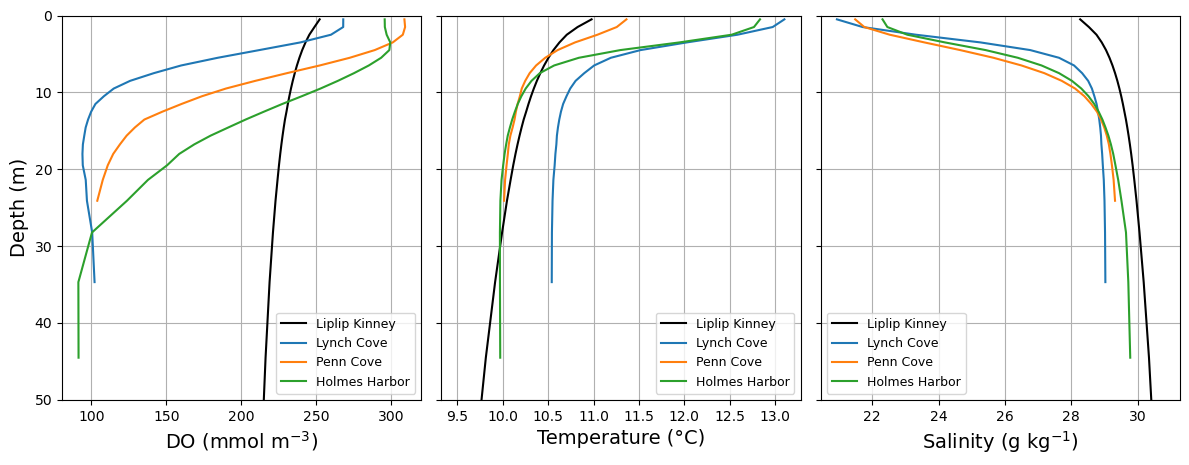

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

titles = ['Dissolved Oxygen', 'Temperature', 'Salinity']
units = [unitO, unitT, unitS]
profile_dicts = [ts_DO_profiles, ts_temp_profiles, ts_salt_profiles]
#colors = ['black', 'tab:blue', 'tab:orange']
for i, (title, unit, ts_profiles) in enumerate(zip(titles, units, profile_dicts)):
    for j, region in enumerate(REGIONS.keys()):
        profiles = [xr.where(prof == 0, np.nan, prof) for _, prof in ts_profiles[region]]
        profiles = np.array(profiles)
        mean_profile = np.nanmean(profiles, axis=0)

        color = 'black' if j == 0 else None  # first region in black
        ax[i].plot(mean_profile, depth_array_1d, label=region, color=color)

    ax[i].invert_yaxis()
    ax[i].set_ylim(50, 0)
    ax[i].set_xlabel(unit, fontsize=14)
    ax[i].grid(True)
    ax[i].legend(fontsize=9)

ax[0].set_ylabel('Depth (m)', fontsize=14)
#fig.suptitle("Mean Vertical Profiles by Region", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
save_fig(fig, "mean_profiles_DO_Temp_Salt_ter")



Plot distribution of DO concentrations (PDFs)

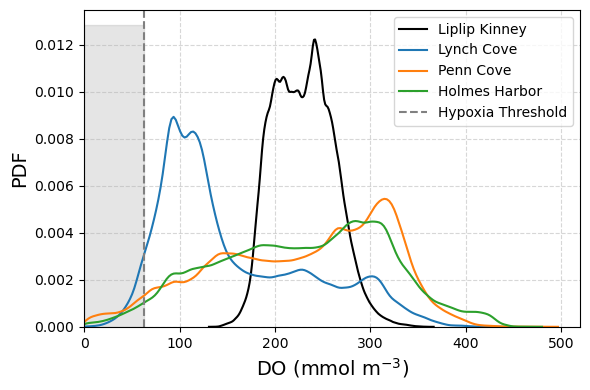

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for i, (region, values_list) in enumerate(all_DO.items()):
    DO_values = np.concatenate(values_list)
    DO_values = DO_values[(~np.isnan(DO_values)) & (DO_values > 0)]

    color = 'black' if i == 0 else None
    sns.kdeplot(DO_values, label=region, color=color)

ax.axvline(63, color='gray', linestyle='--', label='Hypoxia Threshold')
ax.fill_betweenx([0, ax.get_ylim()[1]], 0, 63, color='gray', alpha=0.2)

ax.set_xlabel(unitO, fontsize=14)
ax.set_ylabel("PDF", fontsize=14)
ax.set_xlim(0, 520)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
save_fig(fig, "DO_distribution_PDF_bis")


Lagged correlation: DO vs Temperature, Salinity, Remineralization

In [8]:
def compute_lag_correlation(do_series, var_series, max_lag_days=30):
    # Convert to pandas Series
    do_df = pd.Series(dict(do_series))
    var_df = pd.Series(dict(var_series))

    # Align on common dates
    df = pd.DataFrame({
        'DO': do_df,
        'VAR': var_df
    }).dropna()

    # Compute lag correlations
    lags = np.arange(-max_lag_days, max_lag_days + 1)
    corr_vals = []

    for lag in lags:
        shifted = df['VAR'].shift(lag)
        corr = df['DO'].corr(shifted)
        corr_vals.append(corr)

    return lags, corr_vals

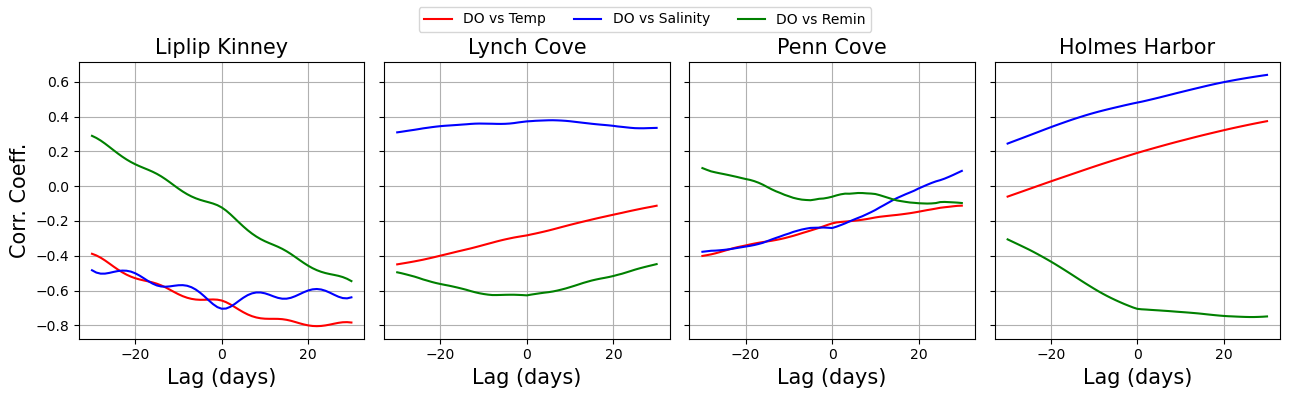

In [14]:
regions_to_analyze = ['Liplip Kinney', 'Lynch Cove', 'Penn Cove', 'Holmes Harbor']
fig, ax = plt.subplots(1, 4, figsize=(13, 4), sharey=True)

for i, region in enumerate(regions_to_analyze):
    rem_vals = [(t, abs(val)) for t, val in daily_min_rem_series[region]]
    #rem_vals = daily_min_rem_series[region]
    # Compute lagged correlations
    lags, corr_temp = compute_lag_correlation(daily_min_DO_series[region], daily_min_temp_series[region])
    _, corr_salt = compute_lag_correlation(daily_min_DO_series[region], daily_min_salt_series[region])
    _, corr_rem = compute_lag_correlation(daily_min_DO_series[region], rem_vals)

    # Plot in subplot
    ax[i].plot(lags, corr_temp, label='DO vs Temp', color='red')
    ax[i].plot(lags, corr_salt, label='DO vs Salinity', color='blue')
    ax[i].plot(lags, corr_rem, label='DO vs Remin', color='green')
    ax[i].set_title(region, fontsize=15)
    ax[i].set_xlabel(f'Lag (days)', fontsize=15)
    ax[i].grid(True)
    if i == 0:
        ax[i].set_ylabel('Corr. Coeff.', fontsize=15)

handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
save_fig(fig, "lagged_correlation_DO_vs_env_vars_bis")

Annual Hypoxic Days vs Temp and Salinity at Min DO

In [18]:
annual_min_DO_do2_day = defaultdict(dict)
annual_min_DO_rem_day = defaultdict(dict)
for region, year_vals in annual_min_DO_do2.items():
    for year, value in year_vals.items():
        annual_min_DO_do2_day[region][year] = value * 86400
for region, year_vals in annual_min_DO_rem.items():
    for year, value in year_vals.items():
        annual_min_DO_rem_day[region][year] = value * 86400

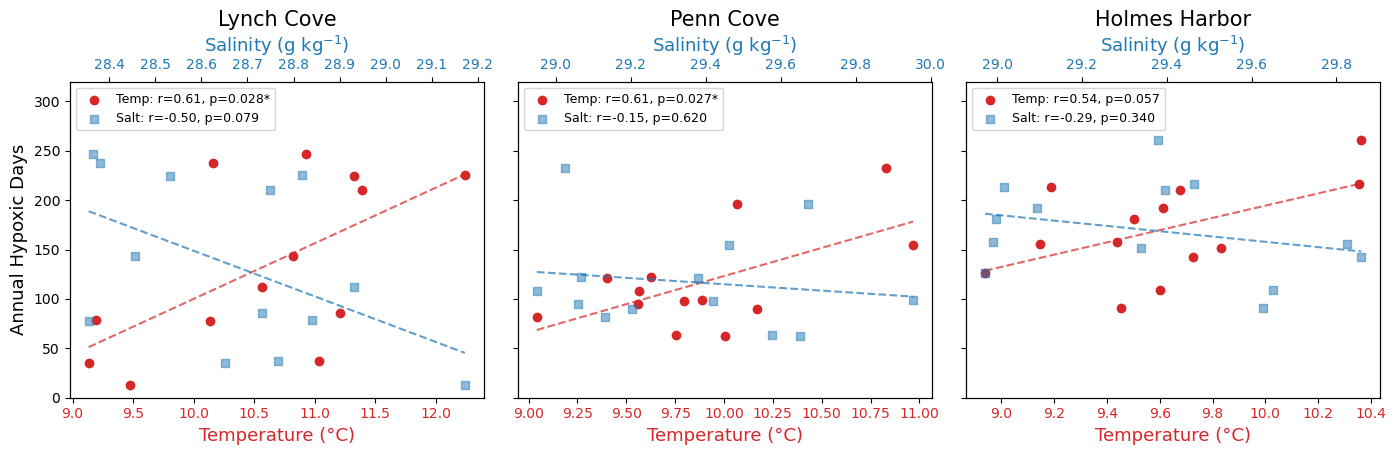

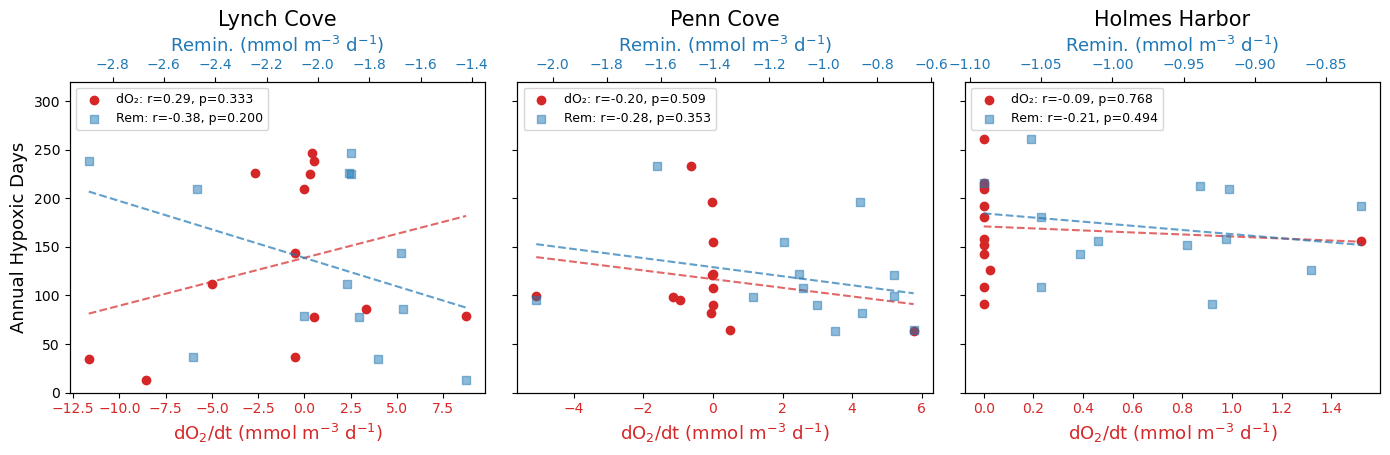

In [22]:
def signif_stars(p):
    if p <= 0.001:
        return '***'
    elif p <= 0.01:
        return '**'
    elif p <= 0.05:
        return '*'
    return ''

def plot_dual_axis(ax, x1, x2, y, label1, label2, color1, color2, xlabel1, xlabel2):
    # Primary axis (x1)
    ax.scatter(x1, y, color=color1, label=label1)
    ax.set_xlabel(xlabel1, color=color1, fontsize=13)
    ax.tick_params(axis='x', labelcolor=color1)
    slope1, intercept1, *_ = linregress(x1, y)
    ax.plot(np.linspace(min(x1), max(x1), 100),
            slope1 * np.linspace(min(x1), max(x1), 100) + intercept1,
            linestyle='--', color=color1, alpha=0.7)

    # Secondary x-axis (x2)
    ax2 = ax.twiny()
    ax2.scatter(x2, y, marker='s', alpha=0.5, color=color2, label=label2)
    ax2.set_xlabel(xlabel2, color=color2, fontsize=13)
    ax2.tick_params(axis='x', labelcolor=color2)
    slope2, intercept2, *_ = linregress(x2, y)
    ax2.plot(np.linspace(min(x2), max(x2), 100),
             slope2 * np.linspace(min(x2), max(x2), 100) + intercept2,
             linestyle='--', color=color2, alpha=0.7)
    
    return ax, ax2

# Part 1: Temp vs Salt
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

regions_last3 = list(REGIONS)[-3:]

for i, region in enumerate(regions_last3):
    ax = axs[i]

    years = sorted(set(annual_hypoxic_days[region]) &
                   set(annual_min_DO_temp[region]) &
                   set(annual_min_DO_salt[region]))

    y_vals = [annual_hypoxic_days[region][y] for y in years]
    x1 = [annual_min_DO_temp[region][y] for y in years]
    x2 = [annual_min_DO_salt[region][y] for y in years]

    r1, p1 = pearsonr(y_vals, x1)
    r2, p2 = pearsonr(y_vals, x2)

    label1 = f'Temp: r={r1:.2f}, p={p1:.3f}{signif_stars(p1)}'
    label2 = f'Salt: r={r2:.2f}, p={p2:.3f}{signif_stars(p2)}'

    ax, ax2 = plot_dual_axis(ax, x1, x2, y_vals, label1, label2,
                             'tab:red', 'tab:blue', unitT, unitS)

    ax.set_title(region, fontsize=15)
    ax.set_ylim(0, 320)

    if i == 0:
        ax.set_ylabel('Annual Hypoxic Days', fontsize=13)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=9)
#plt.suptitle('Annual Hypoxic Days vs Temp and Salinity at Min DO', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
save_fig(fig, "annual_hypoxic_days_vs_temp_salt")

# Part 2: DO₂ vs Remin
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for i, region in enumerate(regions_last3):
    ax = axs[i]
    years = sorted(set(annual_hypoxic_days[region]) &
                   set(annual_min_DO_do2_day[region]) &
                   set(annual_min_DO_rem_day[region]))
    y_vals = [annual_hypoxic_days[region][y] for y in years]
    x1 = [annual_min_DO_do2_day[region][y] for y in years]
    x2 = [annual_min_DO_rem_day[region][y] for y in years]

    r1, p1 = pearsonr(y_vals, x1)
    r2, p2 = pearsonr(y_vals, x2)

    label1 = f'dO₂: r={r1:.2f}, p={p1:.3f}{signif_stars(p1)}'
    label2 = f'Rem: r={r2:.2f}, p={p2:.3f}{signif_stars(p2)}'

    ax, ax2 = plot_dual_axis(ax, x1, x2, y_vals, label1, label2,
                             'tab:red', 'tab:blue', unitRte, unitRmn)

    ax.set_title(region, fontsize=15)
    ax.set_ylim(0, 320)
    if i == 0:
        ax.set_ylabel('Annual Hypoxic Days', fontsize=13)
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=9)

#plt.suptitle('Annual Hypoxic Days vs DO₂ & Remineralization at Min DO', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
save_fig(fig, "annual_hypoxic_days_vs_do2_remin_bis")

In [23]:
# Collect all unique years across all variables and regions
all_years = sorted(set().union(
    *[set(annual_min_DO_temp[r]) for r in REGIONS],
    *[set(annual_min_DO_salt[r]) for r in REGIONS],
    *[set(annual_min_DO_rem_day[r]) for r in REGIONS],
    *[set(annual_min_DO_do2_day[r]) for r in REGIONS],
    *[set(annual_hypoxic_days[r]) for r in REGIONS],
))

# Compile records into a flat table
records = []
for region in REGIONS:
    for year in all_years:
        temp = annual_min_DO_temp[region].get(year)
        salt = annual_min_DO_salt[region].get(year)
        rem = annual_min_DO_rem_day[region].get(year)
        do2 = annual_min_DO_do2_day[region].get(year)
        hyp_days = annual_hypoxic_days[region].get(year)

        # Add entry if at least one value exists
        if any(val is not None for val in [temp, salt, rem, do2, hyp_days]):
            records.append({
                "Region": region,
                "Year": year,
                "Temp (°C)": temp,
                "Salt (g kg$^{-1}$)": salt,
                "Rem (mmol m$^{-3}$ day$^{-1}$)": rem,
                "dO$_2$ (mmol m$^{-3}$ day$^{-1}$)": do2,
                "Hypoxic Days": hyp_days
            })

# Convert to DataFrame
df_combined = pd.DataFrame(records)
df_combined = df_combined.sort_values(by=["Region", "Year"]).reset_index(drop=True)

# Round numeric columns
for col in ["Temp (°C)", "Salt (g kg$^{-1}$)", 
            "Rem (mmol m$^{-3}$ day$^{-1}$)", 
            "dO$_2$ (mmol m$^{-3}$ day$^{-1}$)"]:
    df_combined[col] = df_combined[col].map(lambda x: f"{x:.2f}" if pd.notnull(x) else "--")

# Save as LaTeX table
df_combined.to_latex(
    "annual_min_DO_table.tex",
    index=False,
    escape=False,
    longtable=False,
    caption="Annual minimum DO-associated temperature, salinity, remineralization rate (Rem), DO$_2$ tendency, and hypoxic day count by region and year.",
    label="tab:min_DO_summary"
)

# Optional: preview first few rows
print(df_combined)


           Region  Year Temp (°C) Salt (g kg$^{-1}$)  \
0   Holmes Harbor  2012      8.94              28.97   
1   Holmes Harbor  2013      9.50              29.00   
2   Holmes Harbor  2014      9.19              29.02   
3   Holmes Harbor  2015     10.36              29.38   
4   Holmes Harbor  2016     10.35              29.46   
5   Holmes Harbor  2017      9.44              28.99   
6   Holmes Harbor  2018      9.68              29.40   
7   Holmes Harbor  2019      9.73              29.86   
8   Holmes Harbor  2020      9.15              29.82   
9   Holmes Harbor  2021      9.83              29.34   
10  Holmes Harbor  2022      9.61              29.09   
11  Holmes Harbor  2023      9.45              29.63   
12  Holmes Harbor  2024      9.60              29.65   
13  Liplip Kinney  2012      9.40              32.06   
14  Liplip Kinney  2013      9.27              31.74   
15  Liplip Kinney  2014      9.96              31.96   
16  Liplip Kinney  2015     10.64              3

In [24]:
# Collect all years
all_years = sorted(set().union(
    *[set(annual_min_DO_temp[r]) for r in REGIONS],
    *[set(annual_min_DO_salt[r]) for r in REGIONS],
    *[set(annual_min_DO_rem_day[r]) for r in REGIONS],
    *[set(annual_min_DO_do2_day[r]) for r in REGIONS],
    *[set(annual_hypoxic_days[r]) for r in REGIONS],
))

# Create combined data list
records = []
for region in REGIONS:
    for year in all_years:
        records.append({
            "Region": region,
            "Year": year,
            "Temp_C": annual_min_DO_temp[region].get(year, None),
            "Salt_psu": annual_min_DO_salt[region].get(year, None),
            "Rem_mmol_m3_day": annual_min_DO_rem_day[region].get(year, None),
            "dO2_mmol_m3_day": annual_min_DO_do2_day[region].get(year, None),
            "Hypoxic_Days": annual_hypoxic_days[region].get(year, None)
        })

# Convert to DataFrame
df_combined = pd.DataFrame(records)
df_combined = df_combined.sort_values(["Region", "Year"]).reset_index(drop=True)

# Save to CSV
df_combined.to_csv("annual_min_DO_summary.csv", index=False)


### Cumulative Hypoxic Volume (CHV)

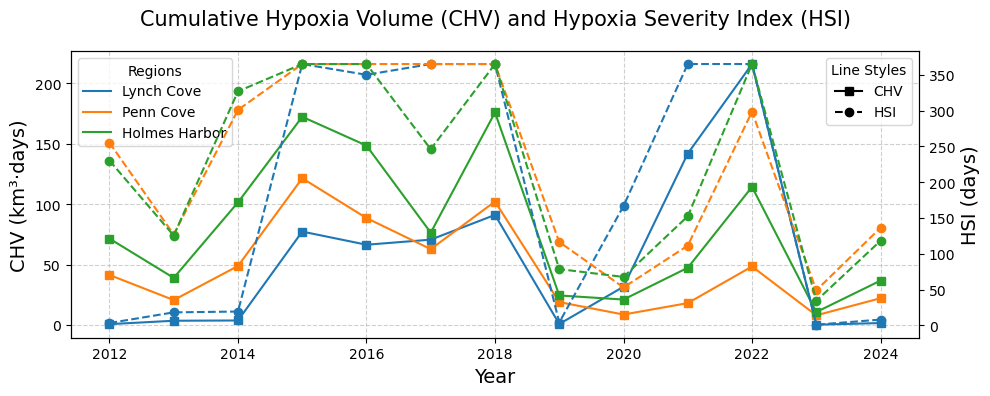

In [28]:
hsi = defaultdict(dict)
normalized_hsi = defaultdict(dict)

# Convert CHV to km³·days and store normalized HSI
for region in REGIONS:
    for year in annual_hypoxic_volume[region]:
        hsi[region][year] = annual_hypoxic_volume[region][year] / 1e9  # m³·days → km³·days
        # Clip HSI at 365 days:
        normalized_hsi[region][year] = min(normalized_hypoxic_volume[region][year], 365)
        
fig, ax1 = plt.subplots(figsize=(10, 4))
region_colors = {
    'Lynch Cove': 'tab:blue',
    'Penn Cove': 'tab:orange',
    'Holmes Harbor': 'tab:green',
}

# Plot CHV on left y-axis
region_handles = []
for region, color in region_colors.items():
    years = sorted(hsi[region])
    chv_vals = [hsi[region][y] for y in years]
    ax1.plot(years, chv_vals, marker='s', linestyle='-', color=color, label=f'{region} CHV')
    region_handles.append(Line2D([0], [0], color=color, label=region))

ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('CHV (km³·days)', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Plot HSI on right y-axis
ax2 = ax1.twinx()
for region, color in region_colors.items():
    years = sorted(normalized_hsi[region])
    hsi_vals = [normalized_hsi[region][y] for y in years]
    ax2.plot(years, hsi_vals, marker='o', linestyle='--', color=color)

ax2.set_ylabel('HSI (days)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combined Legends: One for style, one for region
style_legend = [
    Line2D([0], [0], linestyle='-', marker='s', color='black', label='CHV'),
    Line2D([0], [0], linestyle='--', marker='o', color='black', label='HSI')
]
legend1 = ax1.legend(handles=style_legend, loc='upper right', title='Line Styles')
legend2 = ax1.legend(handles=region_handles, loc='upper left', title='Regions')
ax1.add_artist(legend1)  # Keep first legend after second is added

fig.suptitle('Cumulative Hypoxia Volume (CHV) and Hypoxia Severity Index (HSI)', fontsize=15)
ax1.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
save_fig(fig, "CHV_HSI_by_Region")


### Save results in .csv

In [25]:
#Save daily min DO, temp, salt, remin, do2 for all regions
for var_name, series_dict in [
    ('daily_min_DO', daily_min_DO_series),
    ('daily_min_temp', daily_min_temp_series),
    ('daily_min_salt', daily_min_salt_series),
    ('daily_min_rem', daily_min_rem_series),
    ('daily_min_do2', daily_min_do2_series),
]:
    df = pd.DataFrame({
        region: pd.Series(dict(data))
        for region, data in series_dict.items()
    })
    df.index.name = 'date'
    df.to_csv(f'{var_name}_timeseries.csv')

#Convert nested dict to DataFrame
def nested_dict_to_df(nested_dict):
    return pd.DataFrame(nested_dict).sort_index()

nested_dict_to_df(annual_mean_temp).to_csv("annual_mean_temp.csv")
nested_dict_to_df(annual_mean_salt).to_csv("annual_mean_salt.csv")
nested_dict_to_df(annual_mean_rem).to_csv("annual_mean_rem.csv")
nested_dict_to_df(annual_mean_do2).to_csv("annual_mean_do2.csv")

nested_dict_to_df(annual_hypoxic_days).to_csv("annual_hypoxic_days.csv")
nested_dict_to_df(annual_hypoxic_volume).to_csv("annual_hypoxic_volume.csv")

# Flatten annual min DO-related data
for var_name, nested in [
    ('annual_min_DO', annual_min_DO),
    ('annual_min_DO_temp', annual_min_DO_temp),
    ('annual_min_DO_salt', annual_min_DO_salt),
    ('annual_min_DO_rem', annual_min_DO_rem),
    ('annual_min_DO_do2', annual_min_DO_do2),
]:
    df = pd.DataFrame(nested).sort_index()
    df.to_csv(f"{var_name}.csv")

# Save profiles
os.makedirs("daily_profiles_csv", exist_ok=True)
def save_profile_timeseries(ts_dict, var_name):
    for region, data in ts_dict.items():
        dates, profiles = zip(*data)  # Separate dates and vertical profile arrays
        df = pd.DataFrame(profiles, index=pd.to_datetime(dates))
        df.index.name = 'date'
        df.columns = [f"depth_{k}" for k in range(df.shape[1])]  # Optional: label columns
        out_path = f"daily_profiles_csv/{var_name}_{region}.csv"
        df.to_csv(out_path)

# Save each variable's profiles
save_profile_timeseries(ts_DO_profiles, "DO")
save_profile_timeseries(ts_temp_profiles, "temperature")
save_profile_timeseries(ts_salt_profiles, "salinity")
save_profile_timeseries(ts_rem_profiles, "remineralization")
save_profile_timeseries(ts_do2_profiles, "do2_tendency")
